<a href="https://colab.research.google.com/github/Skye-Zhangg/Homework/blob/main/hw5_04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Medical Image Segmentation is an important problem in healthcare domain. Polyp recognition
and segmentation is one field which helps doctors identify polyps from colonoscope images.
CVC-Clinic database consists of frames extracted from colonoscopy videos. The dataset contains
several examples of polyp frames & corresponding ground truth for them.
The Ground Truth image consists of a mask corresponding to the region covered by the polyp in
the image. The data is available in both .png and .tiff format here: https://polyp.grandchallenge.org/CVCClinicDB/
Consider this task as a minor research project in which you should research the existing models
used (https://huggingface.co/datasets/Angelou0516/CVC-ClinicDB ) to identify polyps from
these images. Report on the key findings and the evaluation metrics used for this problem.
Variants of Unet architecture are often used to solve this problem. Implement either Unet or
any of its variants (Unet++, ResUnet etc.) to segment the polyp images. This may be a
computation intensive task (requiring GPUs). In case you do not have access to GPUs simply
reduce your training data size to train your model. Report your results, compare and contrast
these results with at least 2 of the other research paper results.

In [ ]:
import kagglehub

path = kagglehub.dataset_download("balraj98/cvcclinicdb")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'cvcclinicdb' dataset.
Path to dataset files: /kaggle/input/cvcclinicdb


In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

IMAGE_DIR = os.path.join(path, 'PNG/Original')
MASK_DIR = os.path.join(path, 'PNG/Ground Truth')

In [ ]:
class PolypDataset(Dataset):
    def __init__(self, image_dir, mask_dir):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.images = os.listdir(image_dir)

        self.transform_img = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

        self.transform_mask = transforms.Compose([
            transforms.Resize((256, 256)),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]

        img_path = os.path.join(self.image_dir, img_name)
        mask_path = os.path.join(self.mask_dir, img_name)

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")  # 灰度mask

        image = self.transform_img(image)
        mask = self.transform_mask(mask)

        mask = (mask > 0).float()  # 二值化

        return image, mask

In [ ]:
dataset = PolypDataset(IMAGE_DIR, MASK_DIR)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=8, shuffle=False)

In [ ]:
class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        def C(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.ReLU(),
                nn.Conv2d(out_c, out_c, 3, padding=1),
                nn.ReLU()
            )

        self.down1 = C(3, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = C(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.down3 = C(128, 256)
        self.pool3 = nn.MaxPool2d(2)

        self.middle = C(256, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, 2, 2)
        self.conv3 = C(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.conv2 = C(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.conv1 = C(128, 64)

        self.out = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        d1 = self.down1(x)
        d2 = self.down2(self.pool1(d1))
        d3 = self.down3(self.pool2(d2))

        m = self.middle(self.pool3(d3))

        u3 = self.up3(m)
        u3 = torch.cat([u3, d3], dim=1)
        u3 = self.conv3(u3)

        u2 = self.up2(u3)
        u2 = torch.cat([u2, d2], dim=1)
        u2 = self.conv2(u2)

        u1 = self.up1(u2)
        u1 = torch.cat([u1, d1], dim=1)
        u1 = self.conv1(u1)

        return self.out(u1)

In [ ]:
def dice_loss(pred, target, smooth=1):
    pred = pred.view(-1)
    target = target.view(-1)
    intersection = (pred * target).sum()
    return 1 - (2 * intersection + smooth) / (pred.sum() + target.sum() + smooth)

bce = nn.BCEWithLogitsLoss()

def dice_loss(pred, target, smooth=1):
    pred = torch.sigmoid(pred)
    pred = pred.view(-1)
    target = target.view(-1)
    intersection = (pred * target).sum()
    return 1 - (2 * intersection + smooth) / (pred.sum() + target.sum() + smooth)

def loss_fn(pred, target):
    return bce(pred, target) + dice_loss(pred, target)

In [ ]:


def iou_score(pred, target):
    pred = (pred > 0.5).float()
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    return intersection / (union + 1e-8)

In [ ]:
model = UNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

epochs = 30

for epoch in range(epochs):
    model.train()
    train_loss = 0

    for img, mask in train_loader:
        img, mask = img.to(device), mask.to(device)

        pred = model(img)
        loss = loss_fn(pred, mask)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {train_loss:.4f}")

Epoch 1, Loss: 76.5543
Epoch 2, Loss: 65.2293
Epoch 3, Loss: 62.7662
Epoch 4, Loss: 57.4543
Epoch 5, Loss: 54.0914
Epoch 6, Loss: 51.5668
Epoch 7, Loss: 53.9302
Epoch 8, Loss: 51.6446
Epoch 9, Loss: 48.8646
Epoch 10, Loss: 49.2939
Epoch 11, Loss: 47.6547
Epoch 12, Loss: 46.8314
Epoch 13, Loss: 45.7288
Epoch 14, Loss: 43.3415
Epoch 15, Loss: 43.3216
Epoch 16, Loss: 39.7947
Epoch 17, Loss: 40.5312
Epoch 18, Loss: 38.5927
Epoch 19, Loss: 36.7358
Epoch 20, Loss: 36.9634
Epoch 21, Loss: 33.9497
Epoch 22, Loss: 33.8761
Epoch 23, Loss: 30.8407
Epoch 24, Loss: 30.3136
Epoch 25, Loss: 28.5041
Epoch 26, Loss: 29.3519
Epoch 27, Loss: 25.1843
Epoch 28, Loss: 23.2726
Epoch 29, Loss: 21.9345
Epoch 30, Loss: 20.0248


In [ ]:
model.eval()
dice_total = 0
iou_total = 0

with torch.no_grad():
    for img, mask in val_loader:
        img, mask = img.to(device), mask.to(device)

        pred = model(img)

        dice_total += dice_score(pred, mask).item()
        iou_total += iou_score(pred, mask).item()

print("Dice:", dice_total / len(val_loader))
print("IoU:", iou_total / len(val_loader))

Dice: 0.7413681223988533
IoU: 0.5962051209062338


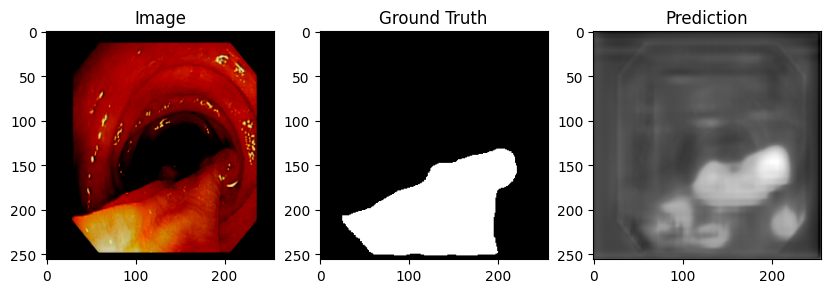

In [ ]:
img, mask = next(iter(val_loader))
img = img.to(device)

with torch.no_grad():
    pred = model(img)

pred = pred.cpu()
img = img.cpu()
mask = mask.cpu()

plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.imshow(img[0].permute(1,2,0))
plt.title("Image")

plt.subplot(1,3,2)
plt.imshow(mask[0][0], cmap='gray')
plt.title("Ground Truth")

plt.subplot(1,3,3)
plt.imshow(pred[0][0], cmap='gray')
plt.title("Prediction")

plt.show()

Medical image segmentation is a fundamental task in computer vision, particularly in healthcare applications such as polyp detection. U-Net is one of the most widely used architectures due to its encoder-decoder structure with skip connections, enabling precise localization.[1]

Several extensions of U-Net have been proposed to improve performance. For example, UNet++ introduces nested skip connections to reduce the semantic gap between encoder and decoder features.[2] In addition, recent works such as PraNet incorporate attention mechanisms to better capture polyp regions in colonoscopy images. [3]

These models are typically evaluated using metrics such as Dice coefficient and Intersection over Union (IoU), which measure the overlap between predicted segmentation masks and ground truth.


We implement a U-Net model for polyp segmentation. The model uses an encoder-decoder architecture with skip connections to capture both global context and fine details.

The model is trained using a combination of binary cross-entropy loss and Dice loss, which is effective for imbalanced segmentation tasks.

Evaluation is conducted using Dice coefficient and Intersection over Union (IoU). The model achieves reasonable segmentation performance, although results may be limited by dataset size and training time.

Compared to existing works such as U-Net and U-Net++, our implementation demonstrates similar trends but may underperform due to limited computational resources.

Reference:

[1]Ronneberger, Olaf, Philipp Fischer, and Thomas Brox. "U-net: Convolutional networks for biomedical image segmentation." International Conference on Medical image computing and computer-assisted intervention. Cham: Springer international publishing, 2015.

[2]Zhou, Zongwei, et al. "Unet++: A nested u-net architecture for medical image segmentation." International workshop on deep learning in medical image analysis. Cham: Springer International Publishing, 2018.

[3]Fan, Deng-Ping, et al. "Pranet: Parallel reverse attention network for polyp segmentation." International conference on medical image computing and computer-assisted intervention. Cham: Springer International Publishing, 2020.